<a href="https://colab.research.google.com/github/AkankshaB123/ML/blob/main/Churn_Prediction_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

# =============================================================================
# Logistic Regression
# =============================================================================
# =============================================================================
# Business Case - Churn Modelling
# =============================================================================
# Setting the Environment
# =============================================================================
import os
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
plt.rc("font", size=14)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

In [3]:
# =============================================================================
# # Importing the dataset
# =============================================================================

data = pd.read_csv('/content/sample_data/Churn_Modelling.csv', header=0)
data = data.dropna()
print(data.shape)
print(list(data.columns))

(10000, 14)
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [6]:
data.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# =============================================================================
# Data Pre-Processing
# =============================================================================

#Creating the Dependent and Independent Features
X = data.iloc[:, 3:13].values
y = data.iloc[:, 13].values

# EDA

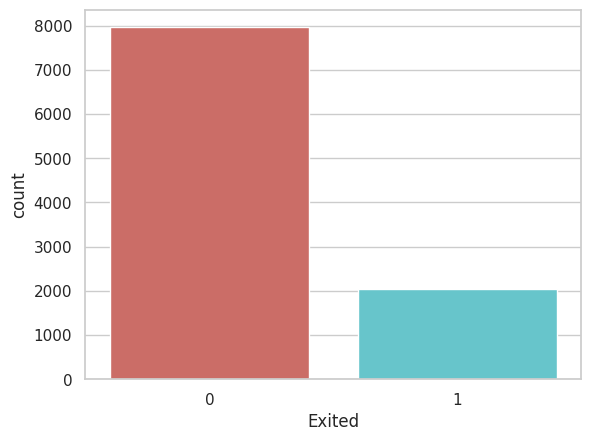

In [11]:
# =============================================================================
# # Exploratory Data Analysis
# =============================================================================


# =============================================================================
# 1. Predict variable (desired target)
# y — has the client subscribed a term deposit? (binary: “1”, means “Yes”, “0” means “No”)
# =============================================================================

#Barplot for the dependent variable
sns.countplot(x='Exited',data=data, palette='hls', hue='Exited', legend=False)
plt.show()

In [10]:
#Check the missing values
data.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


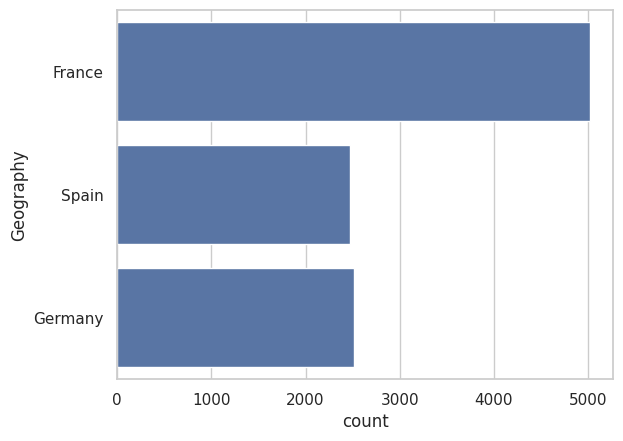

In [13]:
#Customer job distribution
sns.countplot(y="Geography", data=data)
plt.show()

In [15]:
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

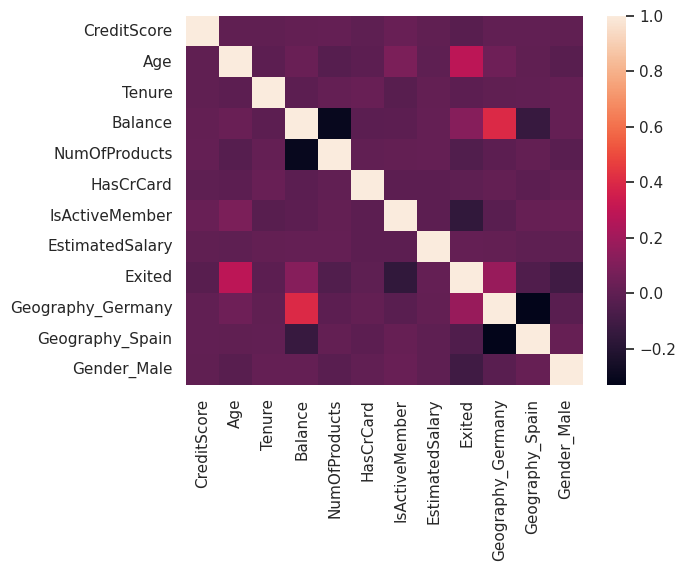

In [19]:
# Reload the dataset to ensure 'data' is in its initial state before transformations
import pandas as pd
data = pd.read_csv('/content/sample_data/Churn_Modelling.csv', header=0)
data = data.dropna()

#Dropping the redundant identifier columns
data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

#Creating Dummy Variables for actual categorical features in Churn_Modelling.csv
data2 = pd.get_dummies(data, columns =['Geography', 'Gender'], drop_first=True)

data2.columns

#Check the independence between the independent variables
sns.heatmap(data2.corr())
plt.show()

In [25]:
# =============================================================================
# Split the data into training and test sets
# =============================================================================
# Correctly assign X as all features except 'Exited', and y as 'Exited'
X = data2.drop('Exited', axis=1)
y = data2['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
X_train.shape

(7500, 11)

In [26]:
# =============================================================================
# Evaluating the Logistic Model
# =============================================================================

# Import LogisticRegression and instantiate the model
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)

# Train the model
classifier.fit(X_train, y_train)

# Predict on the test set and training set
y_pred = classifier.predict(X_test)
y_pred_train = classifier.predict(X_train)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm_train = confusion_matrix(y_train,y_pred_train)

print("Confusion Matrix (Training Set):\n", cm_train)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(classifier.score(X_test, y_test)))


from sklearn.metrics import classification_report
print("\nClassification Report (Test Set):\n", classification_report(y_test, y_pred))

Confusion Matrix (Training Set):
 [[5842  130]
 [1418  110]]
Accuracy of logistic regression classifier on test set: 0.78

Classification Report (Test Set):
               precision    recall  f1-score   support

           0       0.80      0.97      0.88      1991
           1       0.32      0.06      0.10       509

    accuracy                           0.78      2500
   macro avg       0.56      0.51      0.49      2500
weighted avg       0.70      0.78      0.72      2500



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


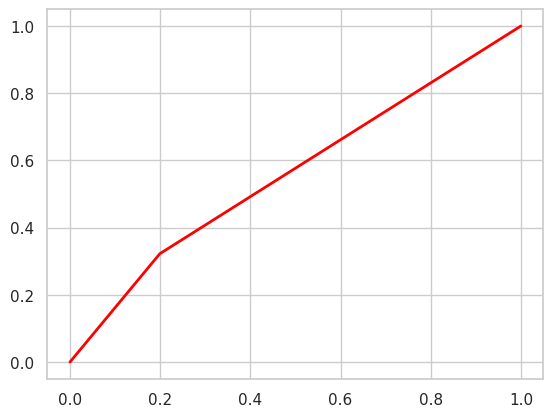

In [27]:
# =============================================================================
# Interpretation:Interpretation: Of the entire test set, 88% of the promoted term deposit were the term deposit that the customers liked. Of the entire test set, 90% of the customer’s preferred term deposits that were promoted.
# =============================================================================


##Computing false and true positive rates
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr,_=roc_curve(classifier.predict(X_test),y_test,drop_intermediate=False)

import matplotlib.pyplot as plt
##Adding the ROC
##Random FPR and TPR

##Title and label
plt.plot(fpr, tpr, color='red',
 lw=2, label='ROC curve')


In [28]:
roc_auc_score(classifier.predict(X_test),y_test)

np.float64(0.5615260488704472)